In [1]:
# Cells model for NN DHS7 2018 v1 overview
# ----------------------------------------
# This file is used as a template base for the automated cell generator notebook.
# favicon in the cell above will be included in the broswer tab title.
# Version, author and date will be included as the first content.

# 🇳🇬 Northern Nigeria Segmentation Overview
<p>
Sonder Segmentation Science WS Team<br>
Data version: DHS7 2018 - v1.0
</p>

In [2]:
# Load libraries
import pandas as pd
import geopandas as gpd
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from plotly.subplots import make_subplots

# Configure Plotly renderer
# this enable chart in the exported HTML file
# https://github.com/microsoft/vscode-jupyter/issues/6999
pio.renderers.default = "notebook_connected"

In [3]:
# R Packages, libraries and utilities
import rpy2.robjects as ro
from rpy2.robjects import r, pandas2ri

In [4]:
# Check R version
r_version = ro.r('version')

In [5]:

pandas2ri.activate()
r('library(survey)')
r('library(base)')
r('library(dplyr)')

R[write to console]: Cargando paquete requerido: grid

R[write to console]: Cargando paquete requerido: Matrix

R[write to console]: Cargando paquete requerido: survival

R[write to console]: 
Adjuntando el paquete: ‘survey’


R[write to console]: The following object is masked from ‘package:graphics’:

    dotchart


R[write to console]: 
Adjuntando el paquete: ‘dplyr’


R[write to console]: The following objects are masked from ‘package:stats’:

    filter, lag


R[write to console]: The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [6]:
regions_dict = {
    'nc benue urban': 'Benue',
    'nc fct abuja urban': 'Abuja',
    'nc kogi urban': 'Kogi',
    'nc kwara urban': 'Kwara',
    'nc nasarawa urban': 'Nasarawa',
    'nc niger urban': 'Niger',
    'nc plateau urban': 'Plateau',
    'ne adamawa urban': 'Adamawa',
    'ne bauchi urban': 'Bauchi',
    'ne borno urban': 'Borno',
    'ne gombe urban': 'Gombe',
    'ne taraba urban': 'Taraba',
    'ne yobe urban': 'Yobe',
    'nw jigawa urban': 'Jigawa',
    'nw kaduna urban': 'Kaduna',
    'nw kano urban': 'Kano',
    'nw katsina urban': 'Katsina',
    'nw kebbi urban': 'Kebbi',
    'nw sokoto urban': 'Sokoto',
    'nw zamfara urban': 'Zamfara',
    'nc benue rural': 'Benue',
    'nc fct abuja rural': 'Abuja',
    'nc kogi rural': 'Kogi',
    'nc kwara rural': 'Kwara',
    'nc nasarawa rural': 'Nasarawa',
    'nc niger rural': 'Niger',
    'nc plateau rural': 'Plateau',
    'ne adamawa rural': 'Adamawa',
    'ne bauchi rural': 'Bauchi',
    'ne borno rural': 'Borno',
    'ne gombe rural': 'Gombe',
    'ne taraba rural': 'Taraba',
    'ne yobe rural': 'Yobe',
    'nw jigawa rural': 'Jigawa',
    'nw kaduna rural': 'Kaduna',
    'nw kano rural': 'Kano',
    'nw katsina rural': 'Katsina',
    'nw kebbi rural': 'Kebbi',
    'nw sokoto rural': 'Sokoto',
    'nw zamfara rural': 'Zamfara'
}

In [7]:
# load data
df = pd.read_csv("North_Nigeria_2018DHS7_1.0_rev.csv")

# Assign new state names
df["State"] = df["v023"].map(regions_dict)

df_rural = df[df["strata"] == "rural"].copy()
df_urban = df[df["strata"] == "urban"].copy()

/var/folders/xf/6wcqzpvn6z32xyywdmn1919c0000gn/T/ipykernel_12417/536462844.py:2: DtypeWarning:

Columns (200,201,428,429,432) have mixed types. Specify dtype option on import or set low_memory=False.



In [8]:
# Load your geojson data (replace with actual path)
geo_df = gpd.read_file('gadm41_NGA_1.json')

In [9]:
# Global variables required in the R runtime:
# ------------------------------------------

# Assign the R DataFrame to an R variable
ro.globalenv['nn'] = df
ro.globalenv['urban'] = df_urban
ro.globalenv['rural'] = df_rural

ro.r('nn$Segment <- factor(nn$segment_name)')
ro.r('urban$Segment <- factor(urban$segment_name)')
ro.r('rural$Segment <- factor(rural$segment_name)')

# Define the survey design in R
# From Michael's design input
ro.r('urban.des <-svydesign(id=urban$v021, strata=urban$v023, weights=urban$wt, survey.lonely.psu="adjust", data=urban)')
ro.r('rural.des <-svydesign(id=rural$v021, strata=rural$v023, weights=rural$wt, survey.lonely.psu="adjust", data=rural)')
ro.r('nn.des <-svydesign(id=nn$v021, strata=nn$v023, weights=nn$wt, survey.lonely.psu="adjust", data=nn)')

/Users/ggojedap/.local/share/virtualenvs/HTML-reports-emoTyqDj/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning:

Error while trying to convert the column "stunt.cat1.last". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.

/Users/ggojedap/.local/share/virtualenvs/HTML-reports-emoTyqDj/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning:

Error while trying to convert the column "dv.physical". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.

/Users/ggojedap/.local/share/virtualenvs/HTML-reports-emoTyqDj/lib/python3.9/site-packages/rpy2/robjects/pandas2

In [10]:
# 'U1.1-NN', 'U1.2-NN', 'U2-NN', 'U3.1-NN', 'U3.2-NN', 'U4-NN',
# 'R2.1-NN', 'R2.2-NN', 'R3-NN', 'R4.1-NN', 'R4.2-NN'
       
colors = {
    "Total": "#FFFFFF",  # White or transparent for root
    "Rural": "#7AC943",  # Blue for Rural category
    "Urban": "#7A8291",  # Green for Urban category
    # Rural segments
    "R2.1-NN": "#14ABF7",
    "R2.2-NN": "#2791c4",
    "R3-NN": "#8B7FEA",
    "R4.1-NN": "#F26185",
    "R4.2-NN": "#bf4b68",
    # Urban segments
    "U1.1-NN": "#21D6D6",
    "U1.2-NN": "#18adad",
    "U2-NN": "#14ABF7",
    "U3.1-NN": "#8B7FEA",
    "U3.2-NN": "#8d84d1",
    "U4-NN": "#F26185"
}

colors_yes_no = {"Yes": "#88C1FD", "No": "#B3B3B3"}

In [11]:
# Function to create contingency tables by demand
def create_table(current_design, var_of_interest, labels={}):
    # create contingency table
    ro.r('current_table <- as.data.frame(svytable(~Segment + ' + var_of_interest + ', design = ' + current_design + '))')
    ro.r('current_table$Segment <- as.character(current_table$Segment)')
    inner_table = ro.r('current_table')
    with (ro.default_converter + pandas2ri.converter).context():
        inner_table = ro.conversion.get_conversion().rpy2py(inner_table)  
    
    # calculate percentage
    inner_total = inner_table.groupby('Segment', observed=False)['Freq'].transform('sum')
    inner_table['percentage'] = inner_table['Freq'] / inner_total * 100
    
    # replace binary for nice values
    inner_table[var_of_interest] = inner_table[var_of_interest].cat.rename_categories(labels)
          
    # remove frequencies to reduce confusion  
    # inner_table = inner_table.drop("Freq", axis=1)
    
    return inner_table

In [12]:
def create_bar_chart(current_data, var_of_interest, title, subtitle=None):
    # Copy and prepare data
    current_data = current_data.copy()
    current_data["percentage"] = current_data["percentage"].round(1)
    current_data["text_label"] = current_data["percentage"].round(1).astype(str) + "%"
    current_data["current_val"] = current_data[var_of_interest]

    # Create the bar chart
    fig = px.bar(
        current_data,
        x='Segment',
        y='percentage',
        color=var_of_interest,
        text='text_label',
        custom_data=["current_val"],
        labels={'percentage': 'Percentage', 'Segment': 'Segment'},
        title=title,
        barmode='stack',
        color_discrete_sequence=[
            "#88C1FD", "#AF73C8", "#66C2A5", "#FB8686", "#FFD92F", "#677BA1", "#B78C4E", "#E78AC3", "#A6D854", "#B3B3B3"
        ],
        color_discrete_map=colors_yes_no
    )

    fig.update_traces(
        textposition='auto',
        cliponaxis=False,
        textfont_size=16,
        hovertemplate=(
            f"<b>{var_of_interest}: %{{customdata[0]}}</b><br>"
            "Segment: %{x}<br>"
            "Percentage: %{text}<extra></extra>"
        )
    )


    # Update layout with styled title
    fig.update_layout(
        title={
            'text': title,
            'x': 0.5,
            'xanchor': 'center',
            'font': dict(size=24, family="Arial", color="#333")
        },
        plot_bgcolor='#fcfcf7',
        paper_bgcolor='#fcfcf7',
        margin=dict(t=100),
        legend_title_text=var_of_interest
    )

    # Add subtitle if provided
    if subtitle:
        fig.add_annotation(
            text=subtitle,
            x=0.5,
            y=1.125,
            xref="paper",
            yref="paper",
            showarrow=False,
            font=dict(size=14, color="gray"),
            xanchor="center"
        )

    return fig


In [13]:
# Calculate stats for a numeric variable, by segment
# min, max, q1, q3, median
def create_stats(current_design, var_of_interest):
  r_code = """
  median <- svyby(~{voi}, ~Segment, {cd}, svyquantile, quantiles = c(0.5), na.rm = TRUE)
  median <- median %>% rename(median = {voi})
  q1 <- svyby(~{voi}, ~Segment, {cd}, svyquantile, quantiles = c(0.25), na.rm = TRUE)
  q1 <- q1 %>%  rename(q1 = {voi})
  q3 <- svyby(~{voi}, ~Segment, {cd}, svyquantile, quantiles = c(0.75), na.rm = TRUE)
  q3 <- q3 %>%  rename(q3 = {voi})
  min <- svyby(~{voi}, ~Segment, {cd}, svyquantile, quantiles = c(0.0), na.rm = TRUE)
  min <- min %>% rename(min = {voi})
  max <- svyby(~{voi}, ~Segment, {cd}, svyquantile, quantiles = c(1.0), na.rm = TRUE)
  max <- max %>% rename(max = {voi})

  stats <- full_join(q1, q3, by = "Segment")
  stats <- full_join(stats, median, by = "Segment")
  stats <- full_join(stats, min, by = "Segment")
  stats <- full_join(stats, max, by = "Segment")

  stats <- stats %>% 
    select("Segment", "min", "q1", "median", "q3", "max")
  """.format(voi=var_of_interest, cd=current_design)

  ro.r(r_code)
  table_stats = ro.r('stats')

  # conversion
  with (ro.default_converter + pandas2ri.converter).context():
          table_stats = ro.conversion.get_conversion().rpy2py(table_stats) 

  return table_stats

In [14]:
def create_box_plot(current_data, var_of_interest, title):
  # Create the box plot
  fig = px.box(
      current_data,
      x="Segment",
      y=["min", "q1", "median", "q3", "max"],
      title="Metrics for " + var_of_interest,
      points=False,  # This hides individual points. "all" to show them
      color="Segment",
      color_discrete_map=colors  # Use custom colors
  )

  # Update layout for better visualization
  fig.update_layout(
      xaxis_title="Segment",
      yaxis_title=var_of_interest,
      title_x=0.5,  # Center the title
      showlegend=True
  )

  # Plot ready to be shown
  return fig

In [15]:
# table cell example, can be removed from template
# for the variable anc.less4 you use:
# -------------------------------------------------
# table_anc_less4 = create_table("nn.des", "anc.less4")
# display(table_anc_less4)

In [16]:
# chart cell example, can be removed from template
# for the variable anc.less4 you use:
# -------------------------------------------------
# create_bar_chart(table_anc_less4, "anc.less4", "Whether Baby Received PNC").show()

In [17]:
# table cell example, can be removed from template
# for the variable partner.age (numeric) you use:
# -------------------------------------------------
# table_partner_age = create_stats("nn.des", "partner.age")
# display(table_partner_age)

In [18]:
# Box plot cell example, can be removed from template
# for the variable partner.age (numeric) you use:
# -------------------------------------------------
# create_box_plot(table_partner_age, "partner.age")

## General Distribution

### Rural Segments

In [19]:
# RURAL Segments 
ro.r('table_dist_rural <- as.data.frame(svytable(~Segment, design = rural.des))')
ro.r('table_dist_rural$Segment <- as.character(table_dist_rural$Segment)')
table_dist_rural = ro.r('table_dist_rural')

# conversion
with (ro.default_converter + pandas2ri.converter).context():
        table_dist_rural = ro.conversion.get_conversion().rpy2py(table_dist_rural)  

# calculate percentage
current_total = table_dist_rural['Freq'].sum()
table_dist_rural['percentage'] = table_dist_rural['Freq'] / current_total * 100

display(table_dist_rural.style.format({'Freq': '{:.0f}', 'percentage': '{:.1f}%'}))

,Segment,Freq,percentage
1,R2.1-NN,2006,14.5%
2,R2.2-NN,1341,9.7%
3,R3-NN,3022,21.8%
4,R4.1-NN,3070,22.2%
5,R4.2-NN,4415,31.9%


### Urban Segments

In [20]:
# URBAN Segments 
ro.r('table_dist_urban <- as.data.frame(svytable(~Segment, design = urban.des))')
ro.r('table_dist_urban$Segment <- as.character(table_dist_urban$Segment)')
table_dist_urban = ro.r('table_dist_urban')

# conversion
with (ro.default_converter + pandas2ri.converter).context():
        table_dist_urban = ro.conversion.get_conversion().rpy2py(table_dist_urban)  

# calculate percentage
current_total = table_dist_urban['Freq'].sum()
table_dist_urban['percentage'] = table_dist_urban['Freq'] / current_total * 100

display(table_dist_urban.style.format({'Freq': '{:.0f}', 'percentage': '{:.1f}%'}))

,Segment,Freq,percentage
1,U1.1-NN,565,11.6%
2,U1.2-NN,971,19.9%
3,U2-NN,811,16.6%
4,U3.1-NN,1000,20.5%
5,U3.2-NN,626,12.8%
6,U4-NN,913,18.7%


### National Distribution

In [21]:
# All NN Segments 
ro.r('table_dist_nn <- as.data.frame(svytable(~Segment, design = nn.des))')
ro.r('table_dist_nn$Segment <- as.character(table_dist_nn$Segment)')
table_dist_nn = ro.r('table_dist_nn')

# conversion
with (ro.default_converter + pandas2ri.converter).context():
        table_dist_nn = ro.conversion.get_conversion().rpy2py(table_dist_nn)  

# calculate percentage
current_total = table_dist_nn['Freq'].sum()
table_dist_nn['percentage'] = table_dist_nn['Freq'] / current_total * 100
table_dist_nn['Type'] = table_dist_nn['Segment'].apply(lambda x: 'Rural' if x.startswith('R') else 'Urban')

display(table_dist_nn.style.format({'Freq': '{:.0f}', 'percentage': '{:.1f}%'}))

,Segment,Freq,percentage,Type
1,R2.1-NN,2006,10.7%,Rural
2,R2.2-NN,1341,7.2%,Rural
3,R3-NN,3022,16.1%,Rural
4,R4.1-NN,3070,16.4%,Rural
5,R4.2-NN,4415,23.6%,Rural
6,U1.1-NN,565,3.0%,Urban
7,U1.2-NN,971,5.2%,Urban
8,U2-NN,811,4.3%,Urban
9,U3.1-NN,1000,5.3%,Urban
10,U3.2-NN,626,3.3%,Urban


In [22]:
# Prepare data for 2 level pie chart (sunburst)
def prepare_sunburst_data(df):
    # Create a copy to avoid modifying the original
    df_sunburst = df.copy()
    
    # Add a root node and type nodes
    root_and_types = pd.DataFrame({
        'Segment': ['Total', 'Rural', 'Urban'],
        'Type': ['', 'Total', 'Total'],  # Empty string for root, Total for Rural/Urban
        'percentage': [100, 
                      df[df['Type'] == 'Rural']['percentage'].sum(),
                      df[df['Type'] == 'Urban']['percentage'].sum()]
    })
    
    # Modify the Type column to point to Rural or Urban instead of Total
    df_sunburst['Type'] = df_sunburst['Type']
    
    # Combine the root and type rows with the data
    df_sunburst = pd.concat([root_and_types, df_sunburst], ignore_index=True)
    
    return df_sunburst

# Prepare the data
sunburst_data = prepare_sunburst_data(table_dist_nn)

In [23]:
# Function to map colors based on the dictionary
def map_colors(df, color_dict):
    return [color_dict[segment] for segment in df['Segment']]

# Create a subplot with two charts (side by side)
fig = make_subplots(
    rows=1, cols=3,  # 1 row and 3 columns
    specs=[[{"type": "pie"}, {"type": "pie"}, {"type": "sunburst"}]],  # Specify type of chart
    subplot_titles=("Rural Distribution", "Urban Distribution", "National Distribution")  # Titles for the subplots
)

# Add the pie chart for table_dist_rural
fig.add_trace(
    go.Pie(
        labels=table_dist_rural['Segment'],
        values=table_dist_rural['percentage'],
        marker=dict(colors=map_colors(table_dist_rural, colors)),  # Apply custom colors
        direction='clockwise',  # Set rotation to clockwise
        sort=False,
        hovertemplate='<b>%{label}</b><br>' +
                      'Percentage: %{value:.2f}%<br>' +
                      '<extra></extra>'  # This removes the secondary box in the hover
    ),
    row=1, col=1  # First row, first column
)

# Add the pie chart for table_dist_urban
fig.add_trace(
    go.Pie(
        labels=table_dist_urban['Segment'],
        values=table_dist_urban['percentage'],
        marker=dict(colors=map_colors(table_dist_urban, colors)),  # Apply custom colors
        direction='clockwise',  # Set rotation to clockwise
        sort=False,
        hovertemplate='<b>%{label}</b><br>' +
                      'Percentage: %{value:.2f}%<br>' +
                      '<extra></extra>'  # This removes the secondary box in the hover
    ),
    row=1, col=2  # First row, second column
)

# Modified sunburst trace
fig.add_trace(
    go.Sunburst(
        ids=sunburst_data['Segment'],
        labels=sunburst_data['Segment'],
        parents=sunburst_data['Type'],
        values=sunburst_data['percentage'],
        marker=dict(colors=map_colors(sunburst_data, colors)),
        branchvalues='total',
        hovertemplate='<b>%{label}</b><br>' +
                      'Percentage: %{value:.2f}%<br>' +
                      '<extra></extra>'  # This removes the secondary box in the hover
    ),
    row=1, col=3
)

# Configure the layout and enforce the category order
fig.update_layout(
    title_text="Segment Distribution",  # Overall title
    title_x=0.5,  # Center the title
    annotations=[{"font": {"size": 14}}]  # Adjust the size of the subplot titles
)

# Show the chart
fig.show()


## Age Distribution

In [24]:
table_age_stats = create_stats("nn.des", "age.yrs")
display(table_age_stats.style.format({'min': '{:.1f}', 'q1': '{:.1f}', 'median': '{:.1f}', 'q3': '{:.1f}', 'max': '{:.1f}'}))

,Segment,min,q1,median,q3,max
1,R2.1-NN,15.0,23.0,30.0,38.0,49.0
2,R2.2-NN,15.0,24.0,30.0,37.0,49.0
3,R3-NN,15.0,23.0,30.0,36.0,49.0
4,R4.1-NN,15.0,25.0,30.0,39.0,49.0
5,R4.2-NN,15.0,21.0,27.0,35.0,49.0
6,U1.1-NN,19.0,28.0,33.0,40.0,49.0
7,U1.2-NN,18.0,28.0,33.0,40.0,49.0
8,U2-NN,17.0,23.0,27.0,34.0,49.0
9,U3.1-NN,15.0,25.0,30.0,39.0,49.0
10,U3.2-NN,15.0,25.0,30.0,38.0,49.0


In [25]:
create_box_plot(table_age_stats, "age.yrs", "Age distribution")

## Geographic Distribution

In [26]:
table_geo_dist_rural = create_table("rural.des", "State")

# calculate alternative percentage
inner_total = table_geo_dist_rural.groupby('State')['Freq'].transform('sum')
table_geo_dist_rural['percentage_state'] = table_geo_dist_rural['Freq'] / inner_total * 100

table_geo_dist_urban = create_table("urban.des", "State")

# calculate alternative percentage
inner_total = table_geo_dist_urban.groupby('State')['Freq'].transform('sum')
table_geo_dist_urban['percentage_state'] = table_geo_dist_urban['Freq'] / inner_total * 100

/var/folders/xf/6wcqzpvn6z32xyywdmn1919c0000gn/T/ipykernel_12417/1118792274.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/xf/6wcqzpvn6z32xyywdmn1919c0000gn/T/ipykernel_12417/1118792274.py:10: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [27]:
# Map with pie charts over each state
# -----------------------------------

# Create the subplots
fig = make_subplots(
    rows=1, cols=2,  # 1 row and 2 columns
    subplot_titles=("Urban Distribution by State", "Rural Distribution by State")  # Titles for the plots
)

# Create a set to track segments already added to the legend
legend_segments = set()

# Urban chart (left side)
for segment in table_geo_dist_urban['Segment'].unique():
    segment_data = table_geo_dist_urban[table_geo_dist_urban['Segment'] == segment]
    fig.add_trace(
        go.Bar(
            x=segment_data['State'],
            y=segment_data['percentage_state'],
            name=segment,  # Segment name for the legend
            legendgroup=segment,  # Same legend group for urban and rural
            showlegend=(segment not in legend_segments),  # Show legend only if not already added
            marker=dict(color=colors.get(segment, "#CCCCCC")),  # Use custom color or default to gray
            text=[f'{x:.1f}%' for x in segment_data['percentage_state']],  
            textposition='inside',  
            hovertemplate='<b>%{x}</b><br>' +
                         'Segment: ' + segment + '<br>' +
                         'Percentage: %{y:.1f}%<br>' +
                         '<extra></extra>'  # This removes the secondary box in the hover
        ),
        row=1, col=1  # Left chart
    )
    legend_segments.add(segment)  # Mark the segment as added

# Rural chart (right side)
for segment in table_geo_dist_rural['Segment'].unique():
    segment_data = table_geo_dist_rural[table_geo_dist_rural['Segment'] == segment]
    fig.add_trace(
        go.Bar(
            x=segment_data['State'],
            y=segment_data['percentage_state'],
            name=segment,  # Segment name for the legend
            legendgroup=segment,  # Same legend group for urban and rural
            showlegend=(segment not in legend_segments),  # Show legend only if not already added
            marker=dict(color=colors.get(segment, "#CCCCCC")),  # Use custom color or default to gray
            text=[f'{x:.1f}%' for x in segment_data['percentage_state']],  
            textposition='inside',  
            hovertemplate='<b>%{x}</b><br>' +
                         'Segment: ' + segment + '<br>' +
                         'Percentage: %{y:.1f}%<br>' +
                         '<extra></extra>'  # This removes the secondary box in the hover
        ),
        row=1, col=2  # Right chart
    )
    legend_segments.add(segment)  # Mark the segment as added

# Configure the layout
fig.update_layout(
    title="Segment Distribution by State (Urban vs Rural)",
    barmode='stack',  # Stack the bars
    title_x=0.5,  # Center the title
    xaxis_title="State",
    yaxis_title="Percentage",
    legend_title="Segment",
)

# Display the charts
fig.show()


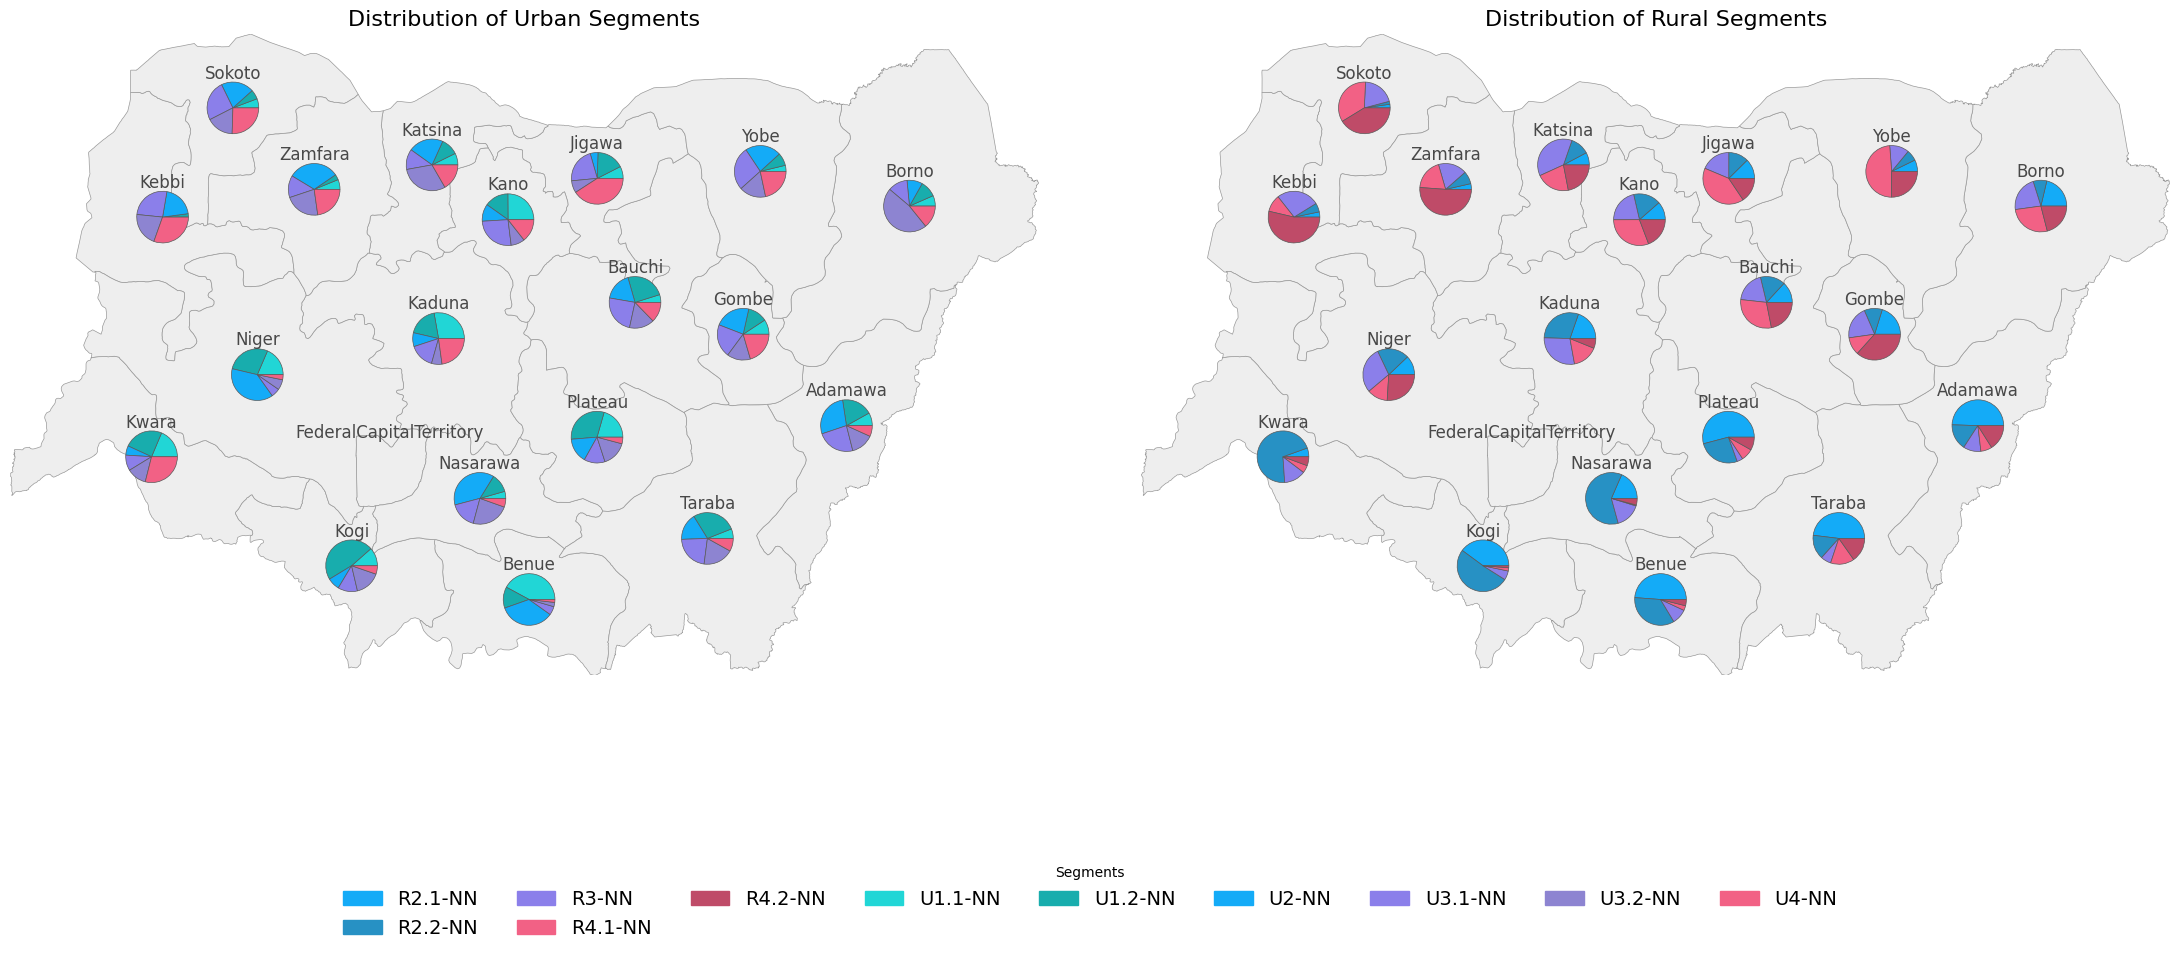

In [28]:
# Create the base map with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(24, 12))  # Two maps side by side

# Plot the base map
geo_df.plot(ax=axes[0], color='#EEE', edgecolor='#999', linewidth=0.5)
axes[0].set_title('Distribution of Urban Segments', fontsize=16)

def plot_pie_for_state(state, x, y, current_table, colors, ax):
    inner_current_table = current_table[current_table['State'] == state]
    
    # Ensure we plot only if there's valid data for this state
    if not inner_current_table.empty:
        sizes = inner_current_table['percentage']
        classes = inner_current_table['Segment']  # Get class names for each segment
        
         # Map each class to its corresponding color using the dictionary
        cls = [colors.get(cl, '#CCCCCC') for cl in classes]  # Default to gray if class not in dict
        ax.pie(sizes, center=(x, y), radius=0.3, colors=cls, wedgeprops=dict(edgecolor='#595959', linewidth=0.5))

# Plot pie charts for urban data
for idx, row in geo_df.iterrows():
    state = row['NAME_1']  # Adjust based on your GeoJSON structure
    centroid = row.geometry.centroid
    plot_pie_for_state(state, centroid.x, centroid.y, table_geo_dist_urban, colors, axes[0])
    # Add state name as a label near the centroid
    axes[0].text(centroid.x, centroid.y + 0.4, state, fontsize=12, ha='center', va='center', color='#484848')

# Plot the second map with rural data
geo_df.plot(ax=axes[1], color='#EEE', edgecolor='#999', linewidth=0.5)
axes[1].set_title('Distribution of Rural Segments', fontsize=16)

# Plot pie charts for rural data
for idx, row in geo_df.iterrows():
    state = row['NAME_1']  # Adjust based on your GeoJSON structure
    centroid = row.geometry.centroid
    plot_pie_for_state(state, centroid.x, centroid.y, table_geo_dist_rural, colors, axes[1])
    # Add state name as a label near the centroid
    axes[1].text(centroid.x, centroid.y + 0.4, state, fontsize=12, ha='center', va='center', color='#484848')

# Add a legend for the pie chart colors excluding Total, Rural, and Urban
excluded_segments = {"Total", "Rural", "Urban"}
legend_handles = [
    mpatches.Patch(color=color, label=segment)
    for segment, color in sorted(colors.items()) if segment not in excluded_segments
]
fig.legend(handles=legend_handles, loc='lower center', ncol=9, fontsize=14, frameon=False, title="Segments")

# Set map limits and hide axes
for ax in axes:
    ax.set_xlim(geo_df.total_bounds[0], geo_df.total_bounds[2])
    ax.set_ylim(geo_df.total_bounds[1], geo_df.total_bounds[3])
    ax.axis('off')

# Adjust layout for a cleaner appearance
plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, wspace=0.1)  # Adjust spacing between subplots

# Show the maps
plt.show()

## 1. Outcomes

### 1.1. ANC/PNC

#### 1.1.1. ANC Less Than 4
*Variable name:* `anc.less4`

In [29]:
table_anc_less4 = create_table("nn.des", "anc.less4", labels={'0': '4+ times', '1': '< 4 times'})

In [30]:
create_bar_chart(table_anc_less4, "anc.less4", "ANC Less Than 4", "Whether respondent had less than 4 ANC visits during last pregnancy").show()

#### 1.1.2. Baby No Health Check < 2 months
*Variable name:* `baby.nohlthck1`

In [31]:
table_baby_nohlthck1 = create_table("nn.des", "baby.nohlthck1", labels={'0': 'Checked', '1': 'No health check'})

In [32]:
create_bar_chart(table_baby_nohlthck1, "baby.nohlthck1", "Baby No Health Check < 2 months", "Whether baby did not have a health check before being discharged or within 2 months of birth").show()

#### 1.1.3. Woman no health check after birth
*Variable name:* `wom.nohlthck1`

In [33]:
table_wom_nohlthck1 = create_table("nn.des", "wom.nohlthck1", labels={'0': 'Checked', '1': 'No health check'})

In [34]:
create_bar_chart(table_wom_nohlthck1, "wom.nohlthck1", "Woman no health check after birth", "Whether Woman did not have a health check after birth").show()

### 1.2. Breastfeeding

#### 1.2.1. Child Breastfed
*Variable name:* `breastfeed.yn`

In [35]:
table_breastfeed_yn = create_table("nn.des", "breastfeed.yn", labels={'0': 'Not breastfed', '1': 'Breastfed'})

In [36]:
create_bar_chart(table_breastfeed_yn, "breastfeed.yn", "Child Breastfed", "Whether The respondent has any child breastfed").show()

### 1.3. Child Mortality

#### 1.3.1. Still births
*Variable name:* `stl.yn`

In [37]:
table_stl_yn = create_table("nn.des", "stl.yn", labels={'0': 'No', '1': 'Yes'})

In [38]:
create_bar_chart(table_stl_yn, "stl.yn", "Still births", "Whether The respondent has experienced a still birth").show()

#### 1.3.2. U1 Mortality
*Variable name:* `u1mort.yn`

In [39]:
table_u1mort_yn = create_table("nn.des", "u1mort.yn", labels={'0': 'No', '1': 'Yes'})

In [40]:
create_bar_chart(table_u1mort_yn, "u1mort.yn", "U1 Mortality", "Whether The respondent has lost a child before the age of 1 year").show()

#### 1.3.3. U5 Mortality
*Variable name:* `u5mort.yn`

In [41]:
table_u5mort_yn = create_table("nn.des", "u5mort.yn", labels={'0': 'No', '1': 'Yes'})

In [42]:
create_bar_chart(table_u5mort_yn, "u5mort.yn", "U5 Mortality", "Whether The respondent has lost a child before the age of 5 years").show()

### 1.4. Family Planning

#### 1.4.1. No Modern FP Used ever
*Variable name:* `nofp.mod.ever`

In [43]:
table_nofp_mod_ever = create_table("nn.des", "nofp.mod.ever", labels={'0': 'Has used FP', '1': 'Never used'})

In [44]:
create_bar_chart(table_nofp_mod_ever, "nofp.mod.ever", "No Modern FP Used ever", "Whether The respondent has never used any planning method").show()

#### 1.4.2. No Modern FP Use Now
*Variable name:* `nofp.mod.now`

In [45]:
table_nofp_mod_now = create_table("nn.des", "nofp.mod.now", labels={'0': 'Currently using', '1': 'Not using'})

In [46]:
create_bar_chart(table_nofp_mod_now, "nofp.mod.now", "No Modern FP Use Now", "Whether The respondent is currently not using any family planning method").show()

### 1.5. Home Births

#### 1.5.1. Last delivery at home
*Variable name:* `hb.1`

In [47]:
table_hb_1 = create_table("nn.des", "hb.1", labels={'0': 'Not at home', '1': 'At home'})

In [48]:
create_bar_chart(table_hb_1, "hb.1", "Last delivery at home", "Whether The respondent had their last delivery at home").show()

### 1.6. Immunization

#### 1.6.1. DPT Immunization
*Variable name:* `dpt.full.yn`

In [49]:
table_dpt_full_yn = create_table("nn.des", "dpt.full.yn", labels={'0': 'Yes', '1': 'No'})

In [50]:
create_bar_chart(table_dpt_full_yn, "dpt.full.yn", "DPT Immunization", "Whether The respondent has a child with DPT immunization").show()

#### 1.6.2. MMR Immunization
*Variable name:* `meas.full.yn`

In [51]:
table_meas_full_yn = create_table("nn.des", "meas.full.yn", labels={'0': 'Not immunized', '1': 'MMR immunized'})

In [52]:
create_bar_chart(table_meas_full_yn, "meas.full.yn", "MMR Immunization", "Whether The respondent has a child with MMR immunization").show()

#### 1.6.3. Child with Polio immunization
*Variable name:* `polio.full.yn`

In [53]:
table_polio_full_yn = create_table("nn.des", "polio.full.yn", labels={'0': 'Yes', '1': 'No'})

In [54]:
create_bar_chart(table_polio_full_yn, "polio.full.yn", "Child with Polio immunization", "Whether The respondent has a child with Polio immunization").show()

#### 1.6.4. Zero Dose Immunization
*Variable name:* `zerodose.yn`

In [55]:
table_zerodose_yn = create_table("nn.des", "zerodose.yn", labels={'0': 'DPT Immunized', '1': 'No immunization'})

In [56]:
create_bar_chart(table_zerodose_yn, "zerodose.yn", "Zero Dose Immunization", "Whether The respondent has a child without DPT immunization").show()

### 1.7. Malnourishment

#### 1.7.1. IDDS
*Variable name:* `idds`

In [57]:
stats_idds = create_stats("nn.des", "idds")

In [58]:
create_box_plot(stats_idds, "idds", "IDDS").show()

#### 1.7.2. Child is overweight
*Variable name:* `ovrwgt.yn`

In [59]:
table_ovrwgt_yn = create_table("nn.des", "ovrwgt.yn", labels={'0': 'No', '1': 'Yes'})

In [60]:
create_bar_chart(table_ovrwgt_yn, "ovrwgt.yn", "Child is overweight", "Whether The respondent has a child who is overweight").show()

#### 1.7.3. Stunted Child
*Variable name:* `stunt.cat2.yn`

In [61]:
table_stunt_cat2_yn = create_table("nn.des", "stunt.cat2.yn", labels={'0': 'No', '1': 'Yes'})

In [62]:
create_bar_chart(table_stunt_cat2_yn, "stunt.cat2.yn", "Stunted Child", "Whether The respondent has a child who is stunted").show()

#### 1.7.4. Child is underweight
*Variable name:* `undwgt.yn`

In [63]:
table_undwgt_yn = create_table("nn.des", "undwgt.yn", labels={'0': 'No', '1': 'Yes'})

In [64]:
create_bar_chart(table_undwgt_yn, "undwgt.yn", "Child is underweight", "Whether The respondent has a child who is underweight").show()

#### 1.7.5. Wasted Child
*Variable name:* `waste.cat2.yn`

In [65]:
table_waste_cat2_yn = create_table("nn.des", "waste.cat2.yn", labels={'0': 'No', '1': 'Yes'})

In [66]:
create_bar_chart(table_waste_cat2_yn, "waste.cat2.yn", "Wasted Child", "Whether The respondent has a child who is wasted").show()

## 2. Defining Variables

### 2.1. Community Support

#### 2.1.1. No FP Reason: Access
*Variable name:* `no.fp.access`

In [67]:
table_no_fp_access = create_table("nn.des", "no.fp.access", labels={})

In [68]:
create_bar_chart(table_no_fp_access, "no.fp.access", "No FP Reason: Access", "Reason for not using FP is lack of access (lack of access, too far or costs too much)").show()

#### 2.1.2. No FP Reason: Not Needed
*Variable name:* `no.fp.noneed`

In [69]:
table_no_fp_noneed = create_table("nn.des", "no.fp.noneed", labels={})

In [70]:
create_bar_chart(table_no_fp_noneed, "no.fp.noneed", "No FP Reason: Not Needed", "Reason for not using FP is not needed").show()

#### 2.1.3. No FP Reason: Partner Oppose
*Variable name:* `no.fp.oppose`

In [71]:
table_no_fp_oppose = create_table("nn.des", "no.fp.oppose", labels={})

In [72]:
create_bar_chart(table_no_fp_oppose, "no.fp.oppose", "No FP Reason: Partner Oppose", "Reason for not using FP is partner's opposition").show()

#### 2.1.4. No FP Reason: Supply
*Variable name:* `no.fp.supply`

In [73]:
table_no_fp_supply = create_table("nn.des", "no.fp.supply", labels={})

In [74]:
create_bar_chart(table_no_fp_supply, "no.fp.supply", "No FP Reason: Supply", "Reason for not using FP is supply").show()

### 2.2. Healthcare and mental models

#### 2.2.1. Condom Last Sex
*Variable name:* `condom.last.sex`

In [75]:
table_condom_last_sex = create_table("nn.des", "condom.last.sex", labels={'0': 'No', '1': 'Yes'})

In [76]:
create_bar_chart(table_condom_last_sex, "condom.last.sex", "Condom Last Sex", "Condom was used during last sex with most recent partner").show()

#### 2.2.2. FP Decision Making
*Variable name:* `desc.fp`

In [77]:
table_desc_fp = create_table("nn.des", "desc.fp", labels={})

In [78]:
create_bar_chart(table_desc_fp, "desc.fp", "FP Decision Making", "Family planning decisions").show()

#### 2.2.3. Family Visit Decision Making
*Variable name:* `desc.visit`

In [79]:
table_desc_visit = create_table("nn.des", "desc.visit", labels={})

In [80]:
create_bar_chart(table_desc_visit, "desc.visit", "Family Visit Decision Making", "Decisions about visiting family or relatives").show()

#### 2.2.4. Partner Opposes FP
*Variable name:* `fp.partner.oppose`

In [81]:
table_fp_partner_oppose = create_table("nn.des", "fp.partner.oppose", labels={})

In [82]:
create_bar_chart(table_fp_partner_oppose, "fp.partner.oppose", "Partner Opposes FP", "Reason for not using FP is husband opposes").show()

#### 2.2.5. HH Cooking Inside
*Variable name:* `hh.cook.inside.yn`

In [83]:
table_hh_cook_inside_yn = create_table("nn.des", "hh.cook.inside.yn", labels={'0': 'No', '1': 'Yes'})

In [84]:
create_bar_chart(table_hh_cook_inside_yn, "hh.cook.inside.yn", "HH Cooking Inside", "Binary variable for food cooked inside the house").show()

#### 2.2.6. Genital Cut Knowledge
*Variable name:* `know.genitalcut`

In [85]:
table_know_genitalcut = create_table("nn.des", "know.genitalcut", labels={'0': 'No', '1': 'Yes'})

In [86]:
create_bar_chart(table_know_genitalcut, "know.genitalcut", "Genital Cut Knowledge", "Ever heard of female circumcision or genital cutting").show()

#### 2.2.7. FP Posters Knowledge
*Variable name:* `m.fp.posters`

In [87]:
table_m_fp_posters = create_table("nn.des", "m.fp.posters", labels={'0': 'No', '1': 'Yes'})

In [88]:
create_bar_chart(table_m_fp_posters, "m.fp.posters", "FP Posters Knowledge", "Read/heard about family planning from social media").show()

#### 2.2.8. Med Barrier: Does Not Want Travel Alone
*Variable name:* `med.alone`

In [89]:
table_med_alone = create_table("nn.des", "med.alone", labels={'0': 'No', '1': 'Yes'})

In [90]:
create_bar_chart(table_med_alone, "med.alone", "Med Barrier: Does Not Want Travel Alone", "Medical barrier: doesn't want to go alone").show()

#### 2.2.9. Med Barrier: Cost
*Variable name:* `med.cost`

In [91]:
table_med_cost = create_table("nn.des", "med.cost", labels={'0': 'No', '1': 'Yes'})

In [92]:
create_bar_chart(table_med_cost, "med.cost", "Med Barrier: Cost", "Medical barrier: cost for necessary treatment").show()

#### 2.2.10. Med Barrier: Distance
*Variable name:* `med.dist`

In [93]:
table_med_dist = create_table("nn.des", "med.dist", labels={'0': 'No', '1': 'Yes'})

In [94]:
create_bar_chart(table_med_dist, "med.dist", "Med Barrier: Distance", "Medical barrier: distance to health facility").show()

#### 2.2.11. Med Barrier: Getting Permission
*Variable name:* `med.permis`

In [95]:
table_med_permis = create_table("nn.des", "med.permis", labels={'0': 'No', '1': 'Yes'})

In [96]:
create_bar_chart(table_med_permis, "med.permis", "Med Barrier: Getting Permission", "Medical barrier to getting medical help for self: getting permission to go").show()

#### 2.2.12. Partner Desire Child
*Variable name:* `partner.desire.child`

In [97]:
table_partner_desire_child = create_table("nn.des", "partner.desire.child", labels={})

In [98]:
create_bar_chart(table_partner_desire_child, "partner.desire.child", "Partner Desire Child", "Categorical variable for children desired by husband/partner").show()

### 2.3. Household economics

#### 2.3.1. HH Owns Animals
*Variable name:* `hh.animal`

In [99]:
table_hh_animal = create_table("nn.des", "hh.animal", labels={'0': 'No', '1': 'Yes'})

In [100]:
create_bar_chart(table_hh_animal, "hh.animal", "HH Owns Animals", "Owns animal(s)").show()

#### 2.3.2. HH Owns a Bike
*Variable name:* `hh.bike`

In [101]:
table_hh_bike = create_table("nn.des", "hh.bike", labels={'0': 'No', '1': 'Yes'})

In [102]:
create_bar_chart(table_hh_bike, "hh.bike", "HH Owns a Bike", "Owns a bike").show()

#### 2.3.3. HH Owns Motor Transport
*Variable name:* `hh.motortransport.yn`

In [103]:
table_hh_motortransport_yn = create_table("nn.des", "hh.motortransport.yn", labels={'0': 'No', '1': 'Yes'})

In [104]:
create_bar_chart(table_hh_motortransport_yn, "hh.motortransport.yn", "HH Owns Motor Transport", "Has motorcycle, scooter, or car").show()

#### 2.3.4. Occupation Type
*Variable name:* `occ.type`

In [105]:
table_occ_type = create_table("nn.des", "occ.type", labels={})

In [106]:
create_bar_chart(table_occ_type, "occ.type", "Occupation Type", "Categorical variable for who respondent works for (family, self, someon else)").show()

#### 2.3.5. Occupation Category
*Variable name:* `occupation.cat`

In [107]:
table_occupation_cat = create_table("nn.des", "occupation.cat", labels={})

In [108]:
create_bar_chart(table_occupation_cat, "occupation.cat", "Occupation Category", "Categorical variable for type of occupation").show()

#### 2.3.6. Partner Working Now
*Variable name:* `part.workingnow.yn`

In [109]:
table_part_workingnow_yn = create_table("nn.des", "part.workingnow.yn", labels={})

In [110]:
create_bar_chart(table_part_workingnow_yn, "part.workingnow.yn", "Partner Working Now", "Binary variable for husband/partner employed currently").show()

#### 2.3.7. Partner Occupation Category
*Variable name:* `partner.occupation.cat`

In [111]:
table_partner_occupation_cat = create_table("nn.des", "partner.occupation.cat", labels={})

In [112]:
create_bar_chart(table_partner_occupation_cat, "partner.occupation.cat", "Partner Occupation Category", "Husband/partner's occupation").show()

#### 2.3.8. Work Seasonal
*Variable name:* `work.seasonal`

In [113]:
table_work_seasonal = create_table("nn.des", "work.seasonal", labels={})

In [114]:
create_bar_chart(table_work_seasonal, "work.seasonal", "Work Seasonal", "Work seasonality").show()

### 2.4. Household relationship

#### 2.4.1. Health Decision Making
*Variable name:* `desc.hlth`

In [115]:
table_desc_hlth = create_table("nn.des", "desc.hlth", labels={})

In [116]:
create_bar_chart(table_desc_hlth, "desc.hlth", "Health Decision Making", "Health decisions").show()

#### 2.4.2. Husband's income decision making
*Variable name:* `desc.money`

In [117]:
table_desc_money = create_table("nn.des", "desc.money", labels={})

In [118]:
create_bar_chart(table_desc_money, "desc.money", "Husband's income decision making", "Decisions about husbands income").show()

#### 2.4.3. First Wife
*Variable name:* `first.wife`

In [119]:
table_first_wife = create_table("nn.des", "first.wife", labels={})

In [120]:
create_bar_chart(table_first_wife, "first.wife", "First Wife", "Categorical variable for wife orded").show()

#### 2.4.4. Head Household Sex
*Variable name:* `head.sex`

In [121]:
table_head_sex = create_table("nn.des", "head.sex", labels={})

In [122]:
create_bar_chart(table_head_sex, "head.sex", "Head Household Sex", "Sex of household head").show()

#### 2.4.5. HH Water Interrupted
*Variable name:* `hh.wat.interrupt`

In [123]:
table_hh_wat_interrupt = create_table("nn.des", "hh.wat.interrupt", labels={})

In [124]:
create_bar_chart(table_hh_wat_interrupt, "hh.wat.interrupt", "HH Water Interrupted", "Water not available for at least a day last two weeks").show()

#### 2.4.6. Number of Sex Partners
*Variable name:* `n.sex.incl.partner.12m`

In [125]:
stats_n_sex_incl_partner_12m = create_stats("nn.des", "n.sex.incl.partner.12m")

In [126]:
create_box_plot(stats_n_sex_incl_partner_12m, "n.sex.incl.partner.12m", "Number of Sex Partners").show()

#### 2.4.7. HH Members age 15+
*Variable name:* `num.15up.cat`

In [127]:
table_num_15up_cat = create_table("nn.des", "num.15up.cat", labels={})

In [128]:
create_bar_chart(table_num_15up_cat, "num.15up.cat", "HH Members age 15+", "Categorical variable for number household members that are 15 or older").show()

#### 2.4.8. HH Members U15
*Variable name:* `num.under15.cat`

In [129]:
table_num_under15_cat = create_table("nn.des", "num.under15.cat", labels={})

In [130]:
create_bar_chart(table_num_under15_cat, "num.under15.cat", "HH Members U15", "Categorical variable for number household members that under 15 years of age").show()

#### 2.4.9. Partner Age Category
*Variable name:* `partner.age`

In [131]:
stats_partner_age = create_stats("nn.des", "partner.age")

In [132]:
create_box_plot(stats_partner_age, "partner.age", "Partner Age Category").show()

#### 2.4.10. Polygamy
*Variable name:* `polygamy`

In [133]:
table_polygamy = create_table("nn.des", "polygamy", labels={'0': 'No', '1': 'Yes'})

In [134]:
create_bar_chart(table_polygamy, "polygamy", "Polygamy", "Type of marriage among married women").show()

#### 2.4.11. Previous Partnership
*Variable name:* `prev.pship`

In [135]:
table_prev_pship = create_table("nn.des", "prev.pship", labels={'0': 'No', '1': 'Yes'})

In [136]:
create_bar_chart(table_prev_pship, "prev.pship", "Previous Partnership", "Previous partnership").show()

#### 2.4.12. Woman's Decision Making Index
*Variable name:* `wd.index`

In [137]:
stats_wd_index = create_stats("nn.des", "wd.index")

In [138]:
create_box_plot(stats_wd_index, "wd.index", "Woman's Decision Making Index").show()

#### 2.4.13. Wife Order
*Variable name:* `wife.order`

In [139]:
table_wife_order = create_table("nn.des", "wife.order", labels={})

In [140]:
create_bar_chart(table_wife_order, "wife.order", "Wife Order", "Respondent's rank among wives").show()

#### 2.4.14. Years Current Partnership
*Variable name:* `yrs.curr.pship`

In [141]:
stats_yrs_curr_pship = create_stats("nn.des", "yrs.curr.pship")

In [142]:
create_box_plot(stats_yrs_curr_pship, "yrs.curr.pship", "Years Current Partnership").show()

### 2.5. Natural and human systems

#### 2.5.1. Internet Use
*Variable name:* `internet.use`

In [143]:
table_internet_use = create_table("nn.des", "internet.use", labels={'0': 'No', '1': 'Yes'})

In [144]:
create_bar_chart(table_internet_use, "internet.use", "Internet Use", "Use of internet last 12 months").show()

### 2.6. Woman and her past experience

#### 2.6.1. Age 1st Cohab
*Variable name:* `age.1stcohab.cat`

In [145]:
table_age_1stcohab_cat = create_table("nn.des", "age.1stcohab.cat", labels={})

In [146]:
create_bar_chart(table_age_1stcohab_cat, "age.1stcohab.cat", "Age 1st Cohab", "Categorical variable for age at first cohabitation w/ partner").show()

#### 2.6.2. Age 1st Sex
*Variable name:* `age.1stsex.cat`

In [147]:
table_age_1stsex_cat = create_table("nn.des", "age.1stsex.cat", labels={})

In [148]:
create_bar_chart(table_age_1stsex_cat, "age.1stsex.cat", "Age 1st Sex", "Categorical variable for age at first sex").show()

#### 2.6.3. Any Education
*Variable name:* `anyed.yn`

In [149]:
table_anyed_yn = create_table("nn.des", "anyed.yn", labels={'0': 'No', '1': 'Yes'})

In [150]:
create_bar_chart(table_anyed_yn, "anyed.yn", "Any Education", "Binary variable for any education for woman").show()

#### 2.6.4. Large HH purchase decision
*Variable name:* `desc.lrgpur`

In [151]:
table_desc_lrgpur = create_table("nn.des", "desc.lrgpur", labels={})

In [152]:
create_bar_chart(table_desc_lrgpur, "desc.lrgpur", "Large HH purchase decision", "Large household purchases").show()

#### 2.6.5. DV Index
*Variable name:* `dv.index.yn`

In [153]:
table_dv_index_yn = create_table("nn.des", "dv.index.yn", labels={})

In [154]:
create_bar_chart(table_dv_index_yn, "dv.index.yn", "DV Index", "Binary variable for DV index (4+)").show()

#### 2.6.6. Educational Attainment
*Variable name:* `ed.lev`

In [155]:
table_ed_lev = create_table("nn.des", "ed.lev", labels={})

In [156]:
create_bar_chart(table_ed_lev, "ed.lev", "Educational Attainment", "Categorical variable for educational attainment").show()

#### 2.6.7. Frequency of listening to radio
*Variable name:* `freq.rad`

In [157]:
table_freq_rad = create_table("nn.des", "freq.rad", labels={})

In [158]:
create_bar_chart(table_freq_rad, "freq.rad", "Frequency of listening to radio", "Frequency of listening to radio").show()

#### 2.6.8. Woman has Bank Account
*Variable name:* `has.bank`

In [159]:
table_has_bank = create_table("nn.des", "has.bank", labels={'0': 'No', '1': 'Yes'})

In [160]:
create_bar_chart(table_has_bank, "has.bank", "Woman has Bank Account", "Has an account in a bank or other financial institution").show()

#### 2.6.9. Woman has Mobile Phone
*Variable name:* `has.mobile`

In [161]:
table_has_mobile = create_table("nn.des", "has.mobile", labels={'0': 'No', '1': 'Yes'})

In [162]:
create_bar_chart(table_has_mobile, "has.mobile", "Woman has Mobile Phone", "Owns a mobile telephone").show()

#### 2.6.10. Joint Decision Index
*Variable name:* `jd.index`

In [163]:
stats_jd_index = create_stats("nn.des", "jd.index")

In [164]:
create_box_plot(stats_jd_index, "jd.index", "Joint Decision Index").show()

#### 2.6.11. Number of Pregnancies
*Variable name:* `num.preg.cat`

In [165]:
table_num_preg_cat = create_table("nn.des", "num.preg.cat", labels={})

In [166]:
create_bar_chart(table_num_preg_cat, "num.preg.cat", "Number of Pregnancies", "Categorical variable for number of pregnancies").show()

#### 2.6.12. HH Members U5
*Variable name:* `num.under5.cat`

In [167]:
table_num_under5_cat = create_table("nn.des", "num.under5.cat", labels={})

In [168]:
create_bar_chart(table_num_under5_cat, "num.under5.cat", "HH Members U5", "Categorical variable for number household members that under 5 years of age").show()

#### 2.6.13. Total Sex Partners
*Variable name:* `total.sex.partners`

In [169]:
table_total_sex_partners = create_table("nn.des", "total.sex.partners", labels={})

In [170]:
create_bar_chart(table_total_sex_partners, "total.sex.partners", "Total Sex Partners", "Total lifetime number of sex partners").show()

#### 2.6.14. Working Now
*Variable name:* `workingnow.yn`

In [171]:
table_workingnow_yn = create_table("nn.des", "workingnow.yn", labels={'0': 'No', '1': 'Yes'})

In [172]:
create_bar_chart(table_workingnow_yn, "workingnow.yn", "Working Now", "Currently working").show()

## 3. Differentiating Variables

### 3.1. Healthcare and mental models

#### 3.1.1. Own Income Decision Making
*Variable name:* `desc.ownincome`

In [173]:
table_desc_ownincome = create_table("nn.des", "desc.ownincome", labels={})

In [174]:
create_bar_chart(table_desc_ownincome, "desc.ownincome", "Own Income Decision Making", "Decisions about own income are made jointly").show()

#### 3.1.2. Discharge Checked Health
*Variable name:* `discharge.checkedhealth`

In [175]:
table_discharge_checkedhealth = create_table("nn.des", "discharge.checkedhealth", labels={})

In [176]:
create_bar_chart(table_discharge_checkedhealth, "discharge.checkedhealth", "Discharge Checked Health", "Who checked respondent health after discharge").show()

#### 3.1.3. Fertility Preference
*Variable name:* `fertility.pref`

In [177]:
table_fertility_pref = create_table("nn.des", "fertility.pref", labels={})

In [178]:
create_bar_chart(table_fertility_pref, "fertility.pref", "Fertility Preference", "Fertility preference categories: Have another, undecided, no more, sterilized/infecund.").show()

#### 3.1.4. Medical Barrier Index
*Variable name:* `med.index`

In [179]:
stats_med_index = create_stats("nn.des", "med.index")

In [180]:
create_box_plot(stats_med_index, "med.index", "Medical Barrier Index").show()

### 3.2. Household economics

#### 3.2.1. HH Clean Fuel
*Variable name:* `hh.clean.fuel`

In [181]:
table_hh_clean_fuel = create_table("nn.des", "hh.clean.fuel", labels={'0': 'No', '1': 'Yes'})

In [182]:
create_bar_chart(table_hh_clean_fuel, "hh.clean.fuel", "HH Clean Fuel", "Type of cooking fuel (electricity, LPG, natural gas, or biogas)").show()

#### 3.2.2. HH Electricity
*Variable name:* `hh.electricity`

In [183]:
table_hh_electricity = create_table("nn.des", "hh.electricity", labels={'0': 'No', '1': 'Yes'})

In [184]:
create_bar_chart(table_hh_electricity, "hh.electricity", "HH Electricity", "Household has electricity").show()

#### 3.2.3. HH Improved Water
*Variable name:* `hh.noimp.water`

In [185]:
table_hh_noimp_water = create_table("nn.des", "hh.noimp.water", labels={'0': 'No', '1': 'Yes'})

In [186]:
create_bar_chart(table_hh_noimp_water, "hh.noimp.water", "HH Improved Water", "Does not have access to an improved source of water").show()

#### 3.2.4. HH Education 7plus
*Variable name:* `highestyearsedinHH.7plus`

In [187]:
table_highestyearsedinHH_7plus = create_table("nn.des", "highestyearsedinHH.7plus", labels={})

In [188]:
create_bar_chart(table_highestyearsedinHH_7plus, "highestyearsedinHH.7plus", "HH Education 7plus", "Binary variable for 7 or more years of education").show()

#### 3.2.5. Mobile Financial
*Variable name:* `mobile.financial`

In [189]:
table_mobile_financial = create_table("nn.des", "mobile.financial", labels={'0': 'No', '1': 'Yes'})

In [190]:
create_bar_chart(table_mobile_financial, "mobile.financial", "Mobile Financial", "Use mobile telephone for financial transactions").show()

#### 3.2.6. Slum Sum
*Variable name:* `slum.sum`

In [191]:
stats_slum_sum = create_stats("nn.des", "slum.sum")

In [192]:
create_box_plot(stats_slum_sum, "slum.sum", "Slum Sum").show()

#### 3.2.7. Wealth Index U/R
*Variable name:* `wealth.index.ur`

In [193]:
table_wealth_index_ur = create_table("nn.des", "wealth.index.ur", labels={})

In [194]:
create_bar_chart(table_wealth_index_ur, "wealth.index.ur", "Wealth Index U/R", "Wealth index for urban/rural").show()

### 3.3. Household relationship

#### 3.3.1. HH Kid-Woman Ratio
*Variable name:* `hh.kidwom.rat.cat`

In [195]:
stats_hh_kidwom_rat_cat = create_stats("nn.des", "hh.kidwom.rat.cat")

In [196]:
create_box_plot(stats_hh_kidwom_rat_cat, "hh.kidwom.rat.cat", "HH Kid-Woman Ratio").show()

### 3.4. Natural and human systems

#### 3.4.1. HH Bank Account
*Variable name:* `hh.bank.acct`

In [197]:
table_hh_bank_acct = create_table("nn.des", "hh.bank.acct", labels={'0': 'No', '1': 'Yes'})

In [198]:
create_bar_chart(table_hh_bank_acct, "hh.bank.acct", "HH Bank Account", "Household has bank account").show()

#### 3.4.2. HH Sanitation
*Variable name:* `hh.sanitation.yn`

In [199]:
table_hh_sanitation_yn = create_table("nn.des", "hh.sanitation.yn", labels={'0': 'No', '1': 'Yes'})

In [200]:
create_bar_chart(table_hh_sanitation_yn, "hh.sanitation.yn", "HH Sanitation", "Categorical variable for HH sanitation").show()

### 3.5. Woman and her past experience

#### 3.5.1. Any Media consumption
*Variable name:* `any.media.yn`

In [201]:
table_any_media_yn = create_table("nn.des", "any.media.yn", labels={'0': 'No', '1': 'Yes'})

In [202]:
create_bar_chart(table_any_media_yn, "any.media.yn", "Any Media consumption", "Binary variable for any news consumption").show()

#### 3.5.2. DV Index
*Variable name:* `dv.index`

In [203]:
stats_dv_index = create_stats("nn.des", "dv.index")

In [204]:
create_box_plot(stats_dv_index, "dv.index", "DV Index").show()

#### 3.5.3. Early cohabitation <15
*Variable name:* `early.cohab.15`

In [205]:
table_early_cohab_15 = create_table("nn.des", "early.cohab.15", labels={'0': 'No', '1': 'Yes'})

In [206]:
create_bar_chart(table_early_cohab_15, "early.cohab.15", "Early cohabitation <15", "Age of first cohabitation was 15 years or younger").show()

#### 3.5.4. Early education attainment
*Variable name:* `ed.lev.low`

In [207]:
table_ed_lev_low = create_table("nn.des", "ed.lev.low", labels={})

In [208]:
create_bar_chart(table_ed_lev_low, "ed.lev.low", "Early education attainment", "Categorical variable to indicate if respondend completed at least primary school").show()

#### 3.5.5. Frequency of watching TV
*Variable name:* `freq.tv`

In [209]:
table_freq_tv = create_table("nn.des", "freq.tv", labels={})

In [210]:
create_bar_chart(table_freq_tv, "freq.tv", "Frequency of watching TV", "Frequency of watching TV").show()

#### 3.5.6. Partner Absent
*Variable name:* `partner.absent.yn`

In [211]:
table_partner_absent_yn = create_table("nn.des", "partner.absent.yn", labels={'0': 'No', '1': 'Yes'})

In [212]:
create_bar_chart(table_partner_absent_yn, "partner.absent.yn", "Partner Absent", "Binary variable for partner absent").show()